# Post-Cleaning Evaluation: Retrain ConvNeXt-Base on Clean Data

**Notebook 10** fixed ground-truth labels (650 removed, 1,296 relabeled). This notebook retrains ConvNeXt-Base from scratch on the cleaned dataset and evaluates it on a held-out test set.

**Why not compare directly with the old model?** The old model was trained on a 75/25 split with no test holdout — ~75% of the new test images were in its training data. Its 95.30% test accuracy reflects memorization, not generalization (its val_acc was only 83.45%). Instead, we compare validation accuracies: **83.45% (dirty) → 84.55% (clean) = +1.1pp from data cleaning alone**.

**Splits**: 75/15/10 train/val/test from the cleaned 203,655-image dataset.

## Section A: Setup & Load Splits

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from utils import (
    Config, set_seed, get_train_transforms, get_val_transforms,
    FoodClassifier, load_class_mapping, save_class_mapping
)

set_seed(Config.SEED)
torch.set_float32_matmul_precision('high')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [3]:
# ── Load 75/15/10 splits ──
SPLIT_ROOT = '../foodsg-233_train_val_test_split'
NUM_CLASSES = 233

# Load class mapping (consistent ordering)
id2label = load_class_mapping('checkpoints/sgfood233_resnet50/id2label.json')
class_names = [id2label[i] for i in range(NUM_CLASSES)]

# Create datasets
train_dataset = ImageFolder(os.path.join(SPLIT_ROOT, 'train'), transform=get_train_transforms())
val_dataset   = ImageFolder(os.path.join(SPLIT_ROOT, 'val'),   transform=get_val_transforms())
test_dataset  = ImageFolder(os.path.join(SPLIT_ROOT, 'test'),  transform=get_val_transforms())

# Verify class ordering
assert train_dataset.classes == class_names, 'Train class ordering mismatch!'
assert val_dataset.classes == class_names, 'Val class ordering mismatch!'
assert test_dataset.classes == class_names, 'Test class ordering mismatch!'

print(f'Train: {len(train_dataset):>7,} images')
print(f'Val:   {len(val_dataset):>7,} images')
print(f'Test:  {len(test_dataset):>7,} images')
print(f'Total: {len(train_dataset) + len(val_dataset) + len(test_dataset):>7,} images')
print(f'Classes: {len(train_dataset.classes)}')

Train: 152,657 images
Val:    30,511 images
Test:   20,487 images
Total: 203,655 images
Classes: 233


In [4]:
# ── DataLoaders ──
BATCH_SIZE = Config.BATCH_SIZE  # 64
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 2386
Val batches:   477
Test batches:  321


## Section B: Evaluate Model

The old ConvNeXt-Base (val_acc 83.45%) was trained on a 75/25 split with no test holdout, so ~75% of the new test images were in its training data. Its 95.30% test score reflects memorization, not generalization. We compare val_acc instead: **83.45% (dirty) → 84.55% (clean) = +1.1pp improvement from data cleaning**.

Below we define an evaluation helper and then retrain ConvNeXt-Base from scratch on the clean data.

In [5]:
# ── Helper: run inference on a dataloader ──
def evaluate_model(model, dataloader, device, desc='Evaluating'):
    """Run inference and return predictions, true labels, and per-class accuracy."""
    model.eval()
    model.to(device)
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=desc):
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # Overall accuracy
    accuracy = (all_preds == all_labels).mean()

    # Per-class accuracy
    per_class_acc = {}
    for c in range(NUM_CLASSES):
        mask = all_labels == c
        if mask.sum() > 0:
            per_class_acc[c] = (all_preds[mask] == c).mean()
        else:
            per_class_acc[c] = float('nan')

    return all_preds, all_labels, accuracy, per_class_acc

## Section C: Retrain ConvNeXt on Clean Data

Same hyperparameters as original training:
- Model: `convnext_base`, pretrained=True
- LR: 1e-4, Weight decay: 1e-4
- Optimizer: AdamW, Scheduler: CosineAnnealingLR (T_max=10, eta_min=1e-6)
- Epochs: 10, Early stopping patience: 3
- Batch size: 64, Precision: 16-mixed

Checkpoint saved to `checkpoints/sgfood233_convnext_base_cleaned/`

In [10]:
# ── Initialize fresh ConvNeXt for retraining ──
MODEL_NAME = 'convnext_base'
EXPERIMENT_NAME = 'sgfood233_convnext_base_cleaned'

new_model = FoodClassifier(
    backbone_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    lr=Config.LEARNING_RATE,        # 1e-4
    weight_decay=Config.WEIGHT_DECAY, # 1e-4
)

total_params = sum(p.numel() for p in new_model.parameters())
print(f'Model: {MODEL_NAME}')
print(f'Parameters: {total_params:,}')
print(f'LR: {Config.LEARNING_RATE}, WD: {Config.WEIGHT_DECAY}')
print(f'Epochs: {Config.MAX_EPOCHS}, Patience: {Config.EARLY_STOP_PATIENCE}')

Model: convnext_base
Parameters: 87,805,289
LR: 0.0001, WD: 0.0001
Epochs: 10, Patience: 3


In [11]:
# ── Setup trainer ──
checkpoint_cb = ModelCheckpoint(
    dirpath=f'checkpoints/{EXPERIMENT_NAME}',
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='{epoch:02d}-{val_acc:.4f}',
)

early_stop_cb = EarlyStopping(
    monitor='val_acc',
    mode='max',
    patience=Config.EARLY_STOP_PATIENCE,
    verbose=True,
)

logger = TensorBoardLogger('logs', name=EXPERIMENT_NAME)

trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,  # 10
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=logger,
    precision='16-mixed' if torch.cuda.is_available() else 32,
    log_every_n_steps=50,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [8]:
# ── Train ──
print(f'Starting training: {EXPERIMENT_NAME}')
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}')
trainer.fit(new_model, train_loader, val_loader)

Starting training: sgfood233_convnext_base_cleaned
Train: 152,657 | Val: 30,511 | Test: 20,487


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt         │ 87.8 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 87.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 87.8 M                                                                                               
Total estimated model params size (MB): 351                                                                        
Modules in train mode: 466                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.832


Metric val_acc improved by 0.006 >= min_delta = 0.0. New best score: 0.838


Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.842


Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.843


Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.845
`Trainer.fit` stopped: `max_epochs=10` reached.


In [9]:
# ── Training results ──
print(f'Best checkpoint: {checkpoint_cb.best_model_path}')
print(f'Best val accuracy: {checkpoint_cb.best_model_score:.4f}')

# Save class mapping
save_class_mapping(id2label, f'checkpoints/{EXPERIMENT_NAME}/id2label.json')
print(f'Class mapping saved.')

Best checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_convnext_base_cleaned\epoch=09-val_acc=0.8455.ckpt
Best val accuracy: 0.8455
Class mapping saved.


## Section D: Evaluate on Test Set

Load the best checkpoint and evaluate on the held-out test set (20,487 images). This model has never seen these images during training.

In [20]:
# ── Evaluate clean-trained model on test set ──
new_best = FoodClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    backbone_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
)
print(f'Loaded checkpoint: {checkpoint_cb.best_model_path}')

new_preds, test_labels, new_accuracy, new_per_class = evaluate_model(
    new_best, test_loader, device, desc='Clean model on test set'
)
del new_best
torch.cuda.empty_cache()

print(f'\nTest accuracy: {new_accuracy:.4f} ({new_accuracy*100:.2f}%)')

Loaded checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_convnext_base_cleaned\epoch=09-val_acc=0.8455.ckpt


Clean model on test set:   0%|          | 0/321 [00:00<?, ?it/s]


Test accuracy: 0.8454 (84.54%)


## Section E: Analysis

In [21]:
# ── Accuracy summary ──
print('=' * 65)
print('ACCURACY SUMMARY')
print('=' * 65)
print()
print(f'{"Model":<40s} {"Val Acc":>8s}  {"Test Acc":>8s}')
print('-' * 65)
print(f'{"Old ConvNeXt (dirty data)*":<40s} {"83.45%":>8s}  {"  n/a":>8s}')
print(f'{"New ConvNeXt (clean data)":<40s} {checkpoint_cb.best_model_score:>8.2%}  {new_accuracy:>8.2%}')
print('-' * 65)
print()
print(f'Cleaning impact (val_acc): 83.45% -> {checkpoint_cb.best_model_score:.2%} '
      f'(+{(checkpoint_cb.best_model_score - 0.8345)*100:.1f}pp)')
print()
print('* Old model test score (95.30%) omitted — data leakage makes it invalid.')

ACCURACY SUMMARY

Model                                     Val Acc  Test Acc
-----------------------------------------------------------------
Old ConvNeXt (dirty data)*                 83.45%       n/a
New ConvNeXt (clean data)                  84.55%    84.54%
-----------------------------------------------------------------

Cleaning impact (val_acc): 83.45% -> 84.55% (+1.1pp)

* Old model test score (95.30%) omitted — data leakage makes it invalid.


In [22]:
# ── Per-class test accuracy (top & bottom 15) ──
rows = []
for c in range(NUM_CLASSES):
    acc = new_per_class[c]
    n_test = (test_labels == c).sum()
    rows.append({
        'class_id': c,
        'class_name': class_names[c],
        'n_test': n_test,
        'test_acc': acc,
    })

df_per_class = pd.DataFrame(rows)

# Top 15 easiest classes
print('Top 15 Classes by Test Accuracy')
print('=' * 65)
top15 = df_per_class.dropna(subset=['test_acc']).nlargest(15, 'test_acc')
for _, row in top15.iterrows():
    print(f"  {row['class_name']:<35s}  {row['test_acc']:>6.1%}  [n={row['n_test']:.0f}]")

print()

# Bottom 15 hardest classes
print('Bottom 15 Classes by Test Accuracy')
print('=' * 65)
bot15 = df_per_class.dropna(subset=['test_acc']).nsmallest(15, 'test_acc')
for _, row in bot15.iterrows():
    print(f"  {row['class_name']:<35s}  {row['test_acc']:>6.1%}  [n={row['n_test']:.0f}]")

Top 15 Classes by Test Accuracy
  egg tart                             100.0%  [n=77]
  pomegranate                          100.0%  [n=52]
  pitaya                                99.2%  [n=124]
  mangosteen                            99.0%  [n=102]
  yuseng                                98.7%  [n=78]
  tumpeng                               98.7%  [n=75]
  sambal kangkong                       98.2%  [n=55]
  rambutan                              98.1%  [n=107]
  Cucumber                              98.1%  [n=53]
  popcorn                               97.8%  [n=181]
  satay                                 97.4%  [n=76]
  ice kacang                            97.3%  [n=73]
  Soursop                               97.2%  [n=72]
  rice dumpling                         97.0%  [n=67]
  Indian Pancake                        96.7%  [n=91]

Bottom 15 Classes by Test Accuracy
  whole wheat                           22.5%  [n=40]
  Bee hoon, soto                        32.3%  [n=62]
  Mee siam

In [23]:
# ── Focus on classes that had the most Tier 1 mislabels ──
FOCUS_CLASSES = [
    'Bee hoon, soto', 'whole wheat', 'bee hoon', 'Mee soto',
    'chicken soup', 'Bee hoon, goreng', 'fried chicken',
    'char siew pau', 'steamed buns', 'har cheong gai',
    'Lontong with sayur lodeh', 'lontong', 'Sweets', 'Chocolate',
    'Seafood Noodles Soup', 'sliced fish soup',
]

print('Test Accuracy for Classes with Most Tier 1 Mislabels')
print('=' * 65)
print(f'  {"Class":<35s}  {"Test Acc":>8s}  {"n"}')
print('-' * 65)
for name in FOCUS_CLASSES:
    if name not in class_names:
        continue
    c = class_names.index(name)
    row = df_per_class.iloc[c]
    if np.isnan(row['test_acc']):
        continue
    marker = ' ***' if row['test_acc'] < 0.7 else ''
    print(f"  {name:<35s}  {row['test_acc']:>8.1%}  [{row['n_test']:.0f}]{marker}")

print()
print('*** = below 70% accuracy (candidates for further investigation)')

Test Accuracy for Classes with Most Tier 1 Mislabels
  Class                                Test Acc  n
-----------------------------------------------------------------
  Bee hoon, soto                          32.3%  [62] ***
  whole wheat                             22.5%  [40] ***
  bee hoon                                45.3%  [64] ***
  Mee soto                                64.3%  [70] ***
  chicken soup                            57.4%  [136] ***
  Bee hoon, goreng                        79.4%  [126]
  fried chicken                           80.1%  [136]
  char siew pau                           75.5%  [102]
  steamed buns                            76.7%  [120]
  har cheong gai                          77.5%  [71]
  Lontong with sayur lodeh                58.3%  [48] ***
  lontong                                 70.8%  [65]
  Sweets                                  88.5%  [261]
  Chocolate                               89.2%  [500]
  Seafood Noodles Soup                    5

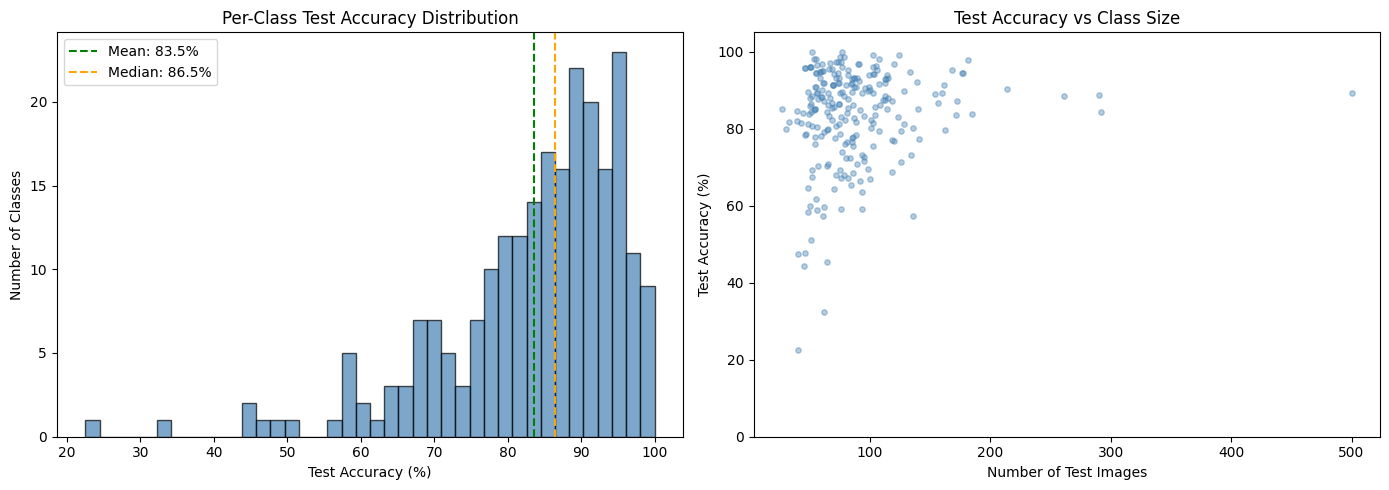

Mean per-class test accuracy: 83.52%
Median: 86.49%
Classes below 50%: 6
Classes above 90%: 80


In [24]:
# ── Per-class test accuracy distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

accs = df_per_class['test_acc'].dropna() * 100

# Histogram
axes[0].hist(accs, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(accs.mean(), color='green', linestyle='--', linewidth=1.5,
                label=f'Mean: {accs.mean():.1f}%')
axes[0].axvline(accs.median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {accs.median():.1f}%')
axes[0].set_xlabel('Test Accuracy (%)')
axes[0].set_ylabel('Number of Classes')
axes[0].set_title('Per-Class Test Accuracy Distribution')
axes[0].legend()

# Accuracy vs class size
axes[1].scatter(df_per_class['n_test'], accs, alpha=0.4, s=15, color='steelblue')
axes[1].set_xlabel('Number of Test Images')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy vs Class Size')
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

print(f'Mean per-class test accuracy: {accs.mean():.2f}%')
print(f'Median: {accs.median():.2f}%')
print(f'Classes below 50%: {(accs < 50).sum()}')
print(f'Classes above 90%: {(accs > 90).sum()}')

In [25]:
# ── Confusion analysis: top confused pairs ──
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, new_preds, labels=range(NUM_CLASSES))

# Top confusion pairs from Tier 1 cleaning
CONFUSION_PAIRS = [
    ('whole wheat', 'whole grain bread'),
    ('char siew pau', 'steamed buns'),
    ('Bee hoon, soto', 'Mee soto'),
    ('chicken soup', 'vegetable soup'),
    ('fried chicken', 'chicken wing'),
    ('har cheong gai', 'fried chicken'),
    ('Lontong with sayur lodeh', 'lontong'),
    ('Seafood Noodles Soup', 'sliced fish soup'),
]

print('Confusion Pair Analysis (test set)')
print('These pairs had the most Tier 1 mislabels — how well does the clean model separate them?')
print('=' * 70)
print(f'  {"True -> Predicted":<45s} {"Count":>6s}  {"True n":>6s}')
print('-' * 70)

for true_name, pred_name in CONFUSION_PAIRS:
    if true_name not in class_names or pred_name not in class_names:
        continue
    ti = class_names.index(true_name)
    pi = class_names.index(pred_name)
    count = cm[ti, pi]
    true_n = (test_labels == ti).sum()
    label = f'{true_name} -> {pred_name}'
    print(f'  {label:<45s} {count:>6d}  {true_n:>6d}')

print('-' * 70)
print('Count = misclassifications. Lower is better.')

Confusion Pair Analysis (test set)
These pairs had the most Tier 1 mislabels — how well does the clean model separate them?
  True -> Predicted                              Count  True n
----------------------------------------------------------------------
  whole wheat -> whole grain bread                  12      40
  char siew pau -> steamed buns                     18     102
  Bee hoon, soto -> Mee soto                         6      62
  chicken soup -> vegetable soup                    15     136
  fried chicken -> chicken wing                      7     136
  har cheong gai -> fried chicken                    8      71
  Lontong with sayur lodeh -> lontong               11      48
  Seafood Noodles Soup -> sliced fish soup          17      76
----------------------------------------------------------------------
Count = misclassifications. Lower is better.


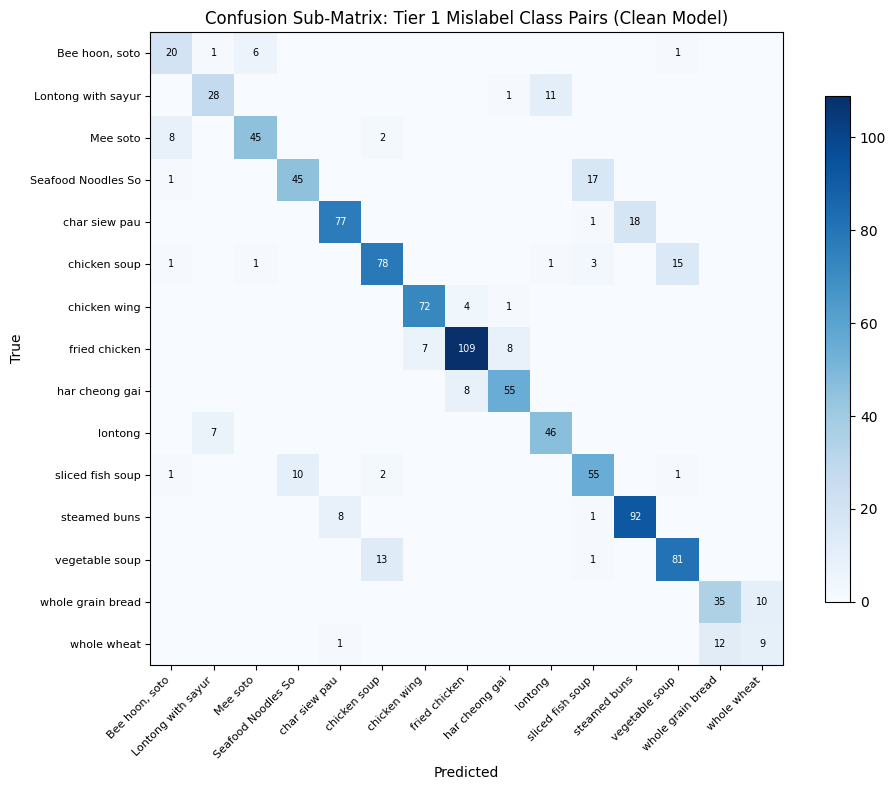

In [26]:
# ── Confusion sub-matrix for top confused class pairs ──
focus_names = sorted(set(
    n for pair in CONFUSION_PAIRS for n in pair if n in class_names
))
focus_ids = [class_names.index(n) for n in focus_names]

sub = cm[np.ix_(focus_ids, focus_ids)]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub, cmap='Blues', interpolation='nearest')
ax.set_xticks(range(len(focus_names)))
ax.set_yticks(range(len(focus_names)))
short_names = [n[:18] for n in focus_names]
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
ax.set_title('Confusion Sub-Matrix: Tier 1 Mislabel Class Pairs (Clean Model)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# Add text annotations
for i in range(len(focus_names)):
    for j in range(len(focus_names)):
        val = sub[i, j]
        if val > 0:
            color = 'white' if val > sub.max() * 0.6 else 'black'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [27]:
# ── Final summary ──
print('=' * 65)
print('POST-CLEANING EVALUATION SUMMARY')
print('=' * 65)
print()
print('Dataset:')
print(f'  Original:  204,305 images (dirty)')
print(f'  Cleaned:   203,655 images (-650 removed, 1,296 relabeled)')
print(f'  Split:     75/15/10 train/val/test ({len(test_dataset):,} test images)')
print()
print('Results:')
print(f'  Old model val_acc (dirty data):   83.45%')
print(f'  New model val_acc (clean data):   {checkpoint_cb.best_model_score:.2%}')
print(f'  Cleaning impact:                  +{(checkpoint_cb.best_model_score - 0.8345)*100:.1f}pp')
print(f'  New model test_acc:               {new_accuracy:.2%}')
print()
print('Note: Old model test score (95.30%) is invalid due to data leakage')
print('(trained on 75/25 split with no test holdout).')
print()
print(f'Checkpoint: {checkpoint_cb.best_model_path}')

POST-CLEANING EVALUATION SUMMARY

Dataset:
  Original:  204,305 images (dirty)
  Cleaned:   203,655 images (-650 removed, 1,296 relabeled)
  Split:     75/15/10 train/val/test (20,487 test images)

Results:
  Old model val_acc (dirty data):   83.45%
  New model val_acc (clean data):   84.55%
  Cleaning impact:                  +1.1pp
  New model test_acc:               84.54%

Note: Old model test score (95.30%) is invalid due to data leakage
(trained on 75/25 split with no test holdout).

Checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_convnext_base_cleaned\epoch=09-val_acc=0.8455.ckpt


---
## Section F: Retrain ResNet-50 and ViT-Base on Clean Data

Same hyperparameters as ConvNeXt retraining (lr=1e-4, wd=1e-4, BS=64, 10 epochs, patience=3).
This gives us a fair before/after comparison for all three architectures.

In [6]:
# ── Train ResNet-50 on clean data ──
MODEL_NAME_R = 'resnet50'
EXPERIMENT_NAME_R = 'sgfood233_resnet50_cleaned'

model_r = FoodClassifier(
    backbone_name=MODEL_NAME_R,
    num_classes=NUM_CLASSES,
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
)

total_params_r = sum(p.numel() for p in model_r.parameters())
print(f'Model: {MODEL_NAME_R}')
print(f'Parameters: {total_params_r:,}')

checkpoint_cb_r = ModelCheckpoint(
    dirpath=f'checkpoints/{EXPERIMENT_NAME_R}',
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='{epoch:02d}-{val_acc:.4f}',
)

early_stop_cb_r = EarlyStopping(
    monitor='val_acc',
    mode='max',
    patience=Config.EARLY_STOP_PATIENCE,
    verbose=True,
)

logger_r = TensorBoardLogger('logs', name=EXPERIMENT_NAME_R)

trainer_r = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[checkpoint_cb_r, early_stop_cb_r],
    logger=logger_r,
    precision='16-mixed' if torch.cuda.is_available() else 32,
    log_every_n_steps=50,
)

print(f'\nStarting training: {EXPERIMENT_NAME_R}')
trainer_r.fit(model_r, train_loader, val_loader)

print(f'\nBest checkpoint: {checkpoint_cb_r.best_model_path}')
print(f'Best val accuracy: {checkpoint_cb_r.best_model_score:.4f}')

save_class_mapping(id2label, f'checkpoints/{EXPERIMENT_NAME_R}/id2label.json')
print('Class mapping saved.')
del model_r
torch.cuda.empty_cache()

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Model: resnet50
Parameters: 23,985,449

Starting training: sgfood233_resnet50_cleaned


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet           │ 24.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 24.0 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.0 M                                                                                               
Total estimated model params size (MB): 95                                                                         
Modules in train mode: 218                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Metric val_acc improved by 0.007 >= min_delta = 0.0. New best score: 0.754


Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.758


Metric val_acc improved by 0.003 >= min_delta = 0.0. New best score: 0.761


`Trainer.fit` stopped: `max_epochs=10` reached.



Best checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_resnet50_cleaned\epoch=08-val_acc=0.7611.ckpt
Best val accuracy: 0.7611
Class mapping saved.


In [7]:
# ── Train ViT-Base on clean data ──
MODEL_NAME_V = 'vit_base_patch16_224'
EXPERIMENT_NAME_V = 'sgfood233_vit_base_patch16_224_cleaned'

model_v = FoodClassifier(
    backbone_name=MODEL_NAME_V,
    num_classes=NUM_CLASSES,
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
)

total_params_v = sum(p.numel() for p in model_v.parameters())
print(f'Model: {MODEL_NAME_V}')
print(f'Parameters: {total_params_v:,}')

checkpoint_cb_v = ModelCheckpoint(
    dirpath=f'checkpoints/{EXPERIMENT_NAME_V}',
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='{epoch:02d}-{val_acc:.4f}',
)

early_stop_cb_v = EarlyStopping(
    monitor='val_acc',
    mode='max',
    patience=Config.EARLY_STOP_PATIENCE,
    verbose=True,
)

logger_v = TensorBoardLogger('logs', name=EXPERIMENT_NAME_V)

trainer_v = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    callbacks=[checkpoint_cb_v, early_stop_cb_v],
    logger=logger_v,
    precision='16-mixed' if torch.cuda.is_available() else 32,
    log_every_n_steps=50,
)

print(f'\nStarting training: {EXPERIMENT_NAME_V}')
trainer_v.fit(model_v, train_loader, val_loader)

print(f'\nBest checkpoint: {checkpoint_cb_v.best_model_path}')
print(f'Best val accuracy: {checkpoint_cb_v.best_model_score:.4f}')

save_class_mapping(id2label, f'checkpoints/{EXPERIMENT_NAME_V}/id2label.json')
print('Class mapping saved.')
del model_v
torch.cuda.empty_cache()

Using 16bit Automatic Mixed Precision (AMP)


Model: vit_base_patch16_224
Parameters: 85,977,833


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting training: sgfood233_vit_base_patch16_224_cleaned


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer │ 86.0 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

...

Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.785


Metric val_acc improved by 0.010 >= min_delta = 0.0. New best score: 0.795


Metric val_acc improved by 0.012 >= min_delta = 0.0. New best score: 0.807


Metric val_acc improved by 0.003 >= min_delta = 0.0. New best score: 0.810
`Trainer.fit` stopped: `max_epochs=10` reached.



Best checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_vit_base_patch16_224_cleaned\epoch=09-val_acc=0.8103.ckpt
Best val accuracy: 0.8103
Class mapping saved.


---
## Section G: Comparative Test-Set Evaluation (All 3 Architectures)

In [15]:
# ── Evaluate all 3 cleaned models on test set ──
import json
import glob

# Find best checkpoints from disk (works after kernel restart)
def find_best_checkpoint(ckpt_dir):
    """Find the checkpoint with highest val_acc in the filename."""
    pattern = os.path.join(ckpt_dir, '*.ckpt')
    ckpts = glob.glob(pattern)
    if not ckpts:
        raise FileNotFoundError(f'No checkpoints found in {ckpt_dir}')
    # Sort by val_acc extracted from filename (e.g., epoch=05-val_acc=0.8455.ckpt)
    return max(ckpts, key=lambda p: float(p.split('val_acc=')[-1].replace('.ckpt', '')))

def get_val_acc_from_path(ckpt_path):
    """Extract val_acc from checkpoint filename."""
    return float(ckpt_path.split('val_acc=')[-1].replace('.ckpt', ''))

# Try to use callback objects if available AND valid, otherwise load from disk
try:
    if checkpoint_cb.best_model_score is not None:
        convnext_ckpt = checkpoint_cb.best_model_path
        convnext_val = float(checkpoint_cb.best_model_score)
    else:
        raise ValueError('No checkpoint saved yet')
except (NameError, ValueError):
    convnext_ckpt = find_best_checkpoint('checkpoints/sgfood233_convnext_base_cleaned')
    convnext_val = get_val_acc_from_path(convnext_ckpt)
    print(f'Loaded ConvNeXt checkpoint from disk: {convnext_ckpt}')

try:
    if checkpoint_cb_r.best_model_score is not None:
        resnet_ckpt = checkpoint_cb_r.best_model_path
        resnet_val = float(checkpoint_cb_r.best_model_score)
    else:
        raise ValueError('No checkpoint saved yet')
except (NameError, ValueError):
    resnet_ckpt = find_best_checkpoint('checkpoints/sgfood233_resnet50_cleaned')
    resnet_val = get_val_acc_from_path(resnet_ckpt)
    print(f'Loaded ResNet-50 checkpoint from disk: {resnet_ckpt}')

try:
    if checkpoint_cb_v.best_model_score is not None:
        vit_ckpt = checkpoint_cb_v.best_model_path
        vit_val = float(checkpoint_cb_v.best_model_score)
    else:
        raise ValueError('No checkpoint saved yet')
except (NameError, ValueError):
    vit_ckpt = find_best_checkpoint('checkpoints/sgfood233_vit_base_patch16_224_cleaned')
    vit_val = get_val_acc_from_path(vit_ckpt)
    print(f'Loaded ViT-Base checkpoint from disk: {vit_ckpt}')

model_configs = {
    'ResNet-50': {
        'backbone': 'resnet50',
        'ckpt_path': resnet_ckpt,
        'clean_val_acc': resnet_val,
        'dirty_val_acc': 0.7509,
    },
    'ViT-Base': {
        'backbone': 'vit_base_patch16_224',
        'ckpt_path': vit_ckpt,
        'clean_val_acc': vit_val,
        'dirty_val_acc': 0.8016,
    },
    'ConvNeXt-Base': {
        'backbone': 'convnext_base',
        'ckpt_path': convnext_ckpt,
        'clean_val_acc': convnext_val,
        'dirty_val_acc': 0.8345,
    },
}

comparison_results = {}
for name, cfg in model_configs.items():
    print(f'\nEvaluating {name}...')
    model_eval = FoodClassifier.load_from_checkpoint(
        cfg['ckpt_path'],
        backbone_name=cfg['backbone'],
        num_classes=NUM_CLASSES,
    )
    _, _, test_acc, _ = evaluate_model(model_eval, test_loader, device, desc=f'{name} on test set')
    del model_eval
    torch.cuda.empty_cache()

    comparison_results[name] = {
        'backbone': cfg['backbone'],
        'dirty_val_acc': cfg['dirty_val_acc'],
        'clean_val_acc': cfg['clean_val_acc'],
        'test_acc': float(test_acc),
        'cleaning_impact_pp': (cfg['clean_val_acc'] - cfg['dirty_val_acc']) * 100,
    }

# Print comparison table
print('\n' + '=' * 80)
print('COMPARATIVE EVALUATION: ALL 3 ARCHITECTURES (CLEANED DATA)')
print('=' * 80)
print(f'\n{"Model":<16s} {"Val Acc (dirty)":>15s} {"Val Acc (clean)":>15s} {"Test Acc (clean)":>16s} {"Impact":>8s}')
print('-' * 80)
for name, r in comparison_results.items():
    print(f'{name:<16s} {r["dirty_val_acc"]:>14.2%} {r["clean_val_acc"]:>14.2%} {r["test_acc"]:>15.2%} {r["cleaning_impact_pp"]:>+7.1f}pp')
print('-' * 80)

# Save results
with open('cleaned_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)
print('\nResults saved to cleaned_comparison_results.json')

Loaded ConvNeXt checkpoint from disk: checkpoints/sgfood233_convnext_base_cleaned\epoch=09-val_acc=0.8455.ckpt

Evaluating ResNet-50...


ResNet-50 on test set:   0%|          | 0/321 [00:11<?, ?it/s]


Evaluating ViT-Base...


ViT-Base on test set:   0%|          | 0/321 [00:00<?, ?it/s]


Evaluating ConvNeXt-Base...


ConvNeXt-Base on test set:   0%|          | 0/321 [00:00<?, ?it/s]


COMPARATIVE EVALUATION: ALL 3 ARCHITECTURES (CLEANED DATA)

Model            Val Acc (dirty) Val Acc (clean) Test Acc (clean)   Impact
--------------------------------------------------------------------------------
ResNet-50                75.09%         76.11%          76.38%    +1.0pp
ViT-Base                 80.16%         81.03%          81.00%    +0.9pp
ConvNeXt-Base            83.45%         84.55%          84.54%    +1.1pp
--------------------------------------------------------------------------------

Results saved to cleaned_comparison_results.json


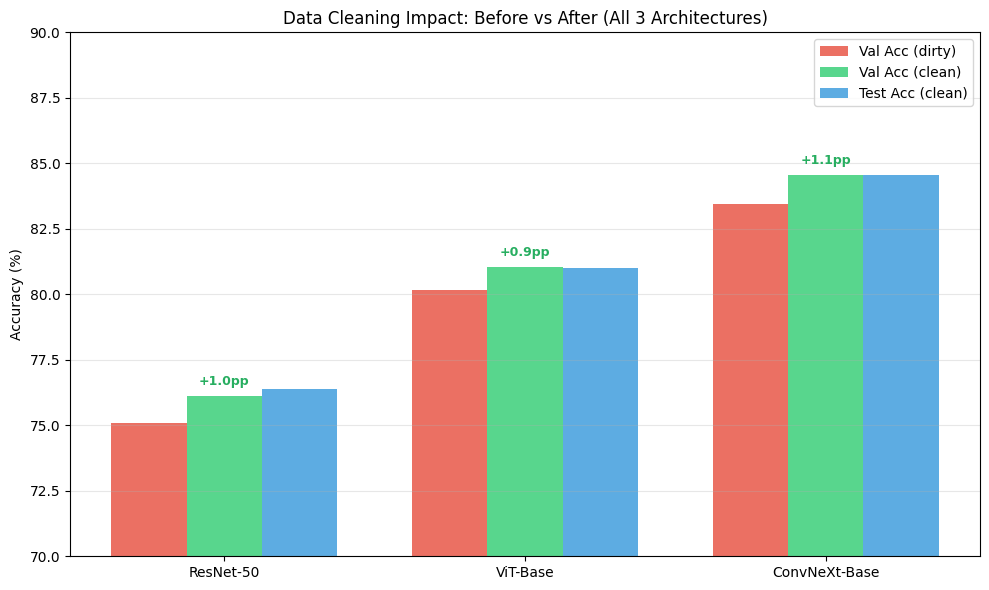

In [16]:
# ── Bar chart: Before/After val_acc for all 3 architectures ──
model_names_plot = list(comparison_results.keys())
dirty_accs = [comparison_results[n]['dirty_val_acc'] * 100 for n in model_names_plot]
clean_accs = [comparison_results[n]['clean_val_acc'] * 100 for n in model_names_plot]
test_accs  = [comparison_results[n]['test_acc'] * 100 for n in model_names_plot]

x = np.arange(len(model_names_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, dirty_accs, width, label='Val Acc (dirty)', color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x, clean_accs, width, label='Val Acc (clean)', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, test_accs, width, label='Test Acc (clean)', color='#3498db', alpha=0.8)

# Annotate cleaning impact
for i, name in enumerate(model_names_plot):
    impact = comparison_results[name]['cleaning_impact_pp']
    ax.annotate(f'+{impact:.1f}pp',
                xy=(i, clean_accs[i]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold', color='#27ae60')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Data Cleaning Impact: Before vs After (All 3 Architectures)')
ax.set_xticks(x)
ax.set_xticklabels(model_names_plot)
ax.legend()
ax.set_ylim(70, 90)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cleaning_impact_comparison.png', dpi=150, bbox_inches='tight')
plt.show()